In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors

In [2]:
hw = pd.read_csv('homework_3.1.csv')
hw

,time,value1,value2,value3
0,0,1.764052,1.883151,-0.369182
1,1,0.420157,-1.327759,-0.219379
2,2,1.018738,-1.230485,1.139660
3,3,2.300893,1.029397,0.715264
4,4,1.947558,-1.093123,0.720132
...,...,...,...,...
95,95,5.856573,3.628454,5.936891
96,96,5.230500,4.611791,4.937725
97,97,7.075870,4.703504,5.462954
98,98,5.486912,6.083236,4.520551


<Axes: xlabel='time', ylabel='value1'>

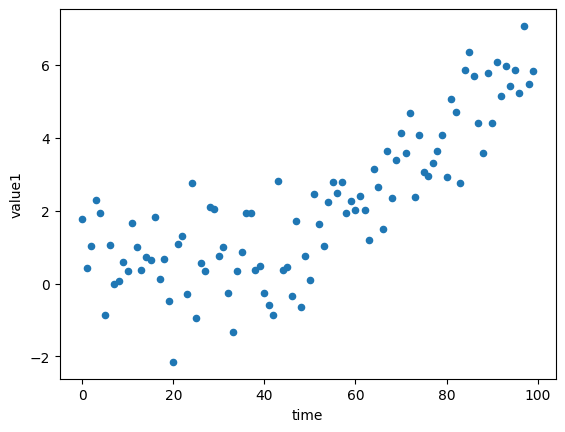

In [3]:
hw.plot.scatter('time','value1')

<Axes: xlabel='time', ylabel='value2'>

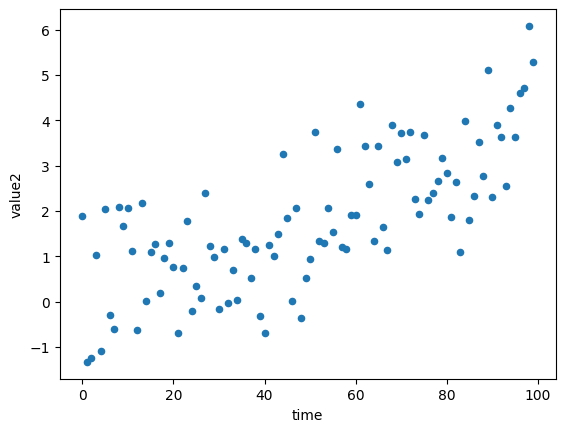

In [4]:
hw.plot.scatter('time','value2')

<Axes: xlabel='time', ylabel='value3'>

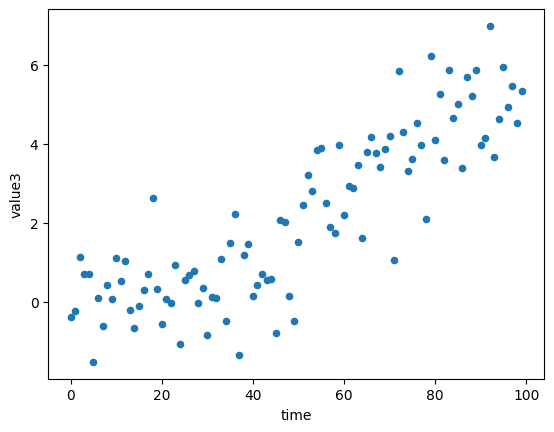

In [5]:
hw.plot.scatter('time','value3')

In [22]:
threshold = 50
for col in hw.columns:
    if col != 'time':
        df = hw[['time',col]]
        dy = np.diff(hw[col])
        dx = np.diff(hw['time'])
        delta = dy/ dx

        discontinuity_indices = np.where(np.abs(np.diff(df)) > threshold)[0]

        # Add +1 to get the exact index where the jump starts
        jump_points = discontinuity_indices + 1 
        print(f"Discontinuities for {col} found at indices: {jump_points}")
        print(f'Num found for {col} is {len(jump_points)}')
        print(f'delta is {max(np.diff(delta))}')

Discontinuities for value1 found at indices: [ 53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100]
Num found for value1 is 48
delta is 5.224244491289054
Discontinuities for value2 found at indices: [ 53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100]
Num found for value2 is 48
delta is 5.259264703807304
Discontinuities for value3 found at indices: [ 54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
Num found for value3 is 47
delta is 7.900144166744125


In [30]:
group1 = pd.read_csv('homework_3.2.a.csv')
group2 = pd.read_csv('homework_3.2.b.csv')


In [55]:
print(group1)

model_g1 = smf.ols(formula="outcome1 ~ time1 * group1", data=group1)
model_g1_1 = smf.ols(formula="outcome1 ~ group1 * time1", data=group1)
results1 = model_g1.fit()
results1_1 = model_g1_1.fit()

# Print the model matrix overview
print(results1.summary())
print("*****"*5)
print("==============New set===============")
print(results1_1.summary())


     group1  time1  outcome1
0         0      0  0.882026
1         0      1  1.600079
2         0      0  0.489369
3         0      1  2.520447
4         0      0  0.933779
..      ...    ...       ...
995       1      1  4.306435
996       1      0  1.900801
997       1      1  4.147096
998       1      0  1.426195
999       1      1  3.920943

[1000 rows x 3 columns]
                            OLS Regression Results                            
Dep. Variable:               outcome1   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     2964.
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:37:02   Log-Likelihood:                -712.28
No. Observations:                1000   AIC:                             1433.
Df Residuals:                     996   BIC:                             1

In [56]:

print(group2)
# Formula equivalent to: outcome ~ treated + post + treated:post
model_g2 = smf.ols(formula="outcome2 ~ time2 * group2", data=group2)
results2 = model_g2.fit()

# Print the model matrix overview
print(results2.summary())


     group2  time2  outcome2
0         0      0  0.667155
1         0      1  2.470969
2         0      0 -0.506778
3         0      1  1.525657
4         0      0  0.273664
..      ...    ...       ...
995       1      1  4.637301
996       1      0  3.681828
997       1      1  4.710121
998       1      0  0.629718
999       1      1  2.946836

[1000 rows x 3 columns]
                            OLS Regression Results                            
Dep. Variable:               outcome2   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     653.6
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          9.62e-235
Time:                        20:38:14   Log-Likelihood:                -1567.5
No. Observations:                1000   AIC:                             3143.
Df Residuals:                     996   BIC:                             3

In [ ]:
### Reference notes

# Seed for reproducibility
np.random.seed(42)

# Parameters
n_units = 100
time_periods = [0, 1]  # 0 = Pre-treatment, 1 = Post-treatment

# Create data grid
unit_ids = np.repeat(np.arange(n_units), len(time_periods))
post_indicator = np.tile(time_periods, n_units)

df = pd.DataFrame({"unit": unit_ids, "post": post_indicator})

# Assign 50% of the units randomly to the treatment group
treated_units = np.random.choice(np.arange(n_units), size=n_units // 2, replace=False)
df["treated"] = df["unit"].isin(treated_units).astype(int)

# Generate baseline outcome with a true treatment effect of 2.5
# Formula: baseline + time trend + group differences + causal effect + noise
df["outcome"] = (
    10
    + 1.5 * df["post"]
    + 0.8 * df["treated"]
    + 2.5 * (df["treated"] * df["post"])
    + np.random.normal(0, 0.5, size=len(df))
)

print(df.head(4))

# Formula equivalent to: outcome ~ treated + post + treated:post
model = smf.ols(formula="outcome ~ treated * post", data=df)
results = model.fit()

# Print the model matrix overview
print(results.summary())


   unit  post  treated    outcome
0     0     0        1  11.118153
1     0     1        1  14.346640
2     1     0        0  10.238021
3     1     1        0  12.151831
                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     868.9
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          6.53e-113
Time:                        20:18:24   Log-Likelihood:                -144.04
No. Observations:                 200   AIC:                             296.1
Df Residuals:                     196   BIC:                             309.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err      